In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.plot_utils import save_figure

In [2]:
DATA_PATH = "../data/raw/divar.csv"

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

In [4]:
df.shape

(1000000, 61)

In [5]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [ ]:
# import dtale
# d = dtale.show(df)
# d.open_browser()

In [7]:
location_cols = ["location_latitude", "location_longitude"]

In [8]:
df[location_cols].isna().sum()

location_latitude     344392
location_longitude    344392
dtype: int64

In [9]:
df[location_cols].describe()

,location_latitude,location_longitude
count,655608.000000,655608.000000
mean,34.982108,51.629743
std,2.379169,3.160920
min,23.626478,40.162369
25%,34.553551,50.677175
50%,35.723312,51.345791
75%,36.307013,51.805291
max,40.358055,74.511620


In [10]:
geo_df = df.dropna(subset=location_cols).copy()

In [11]:
geo_df.shape

(655608, 61)

In [ ]:
# geo_df = geo_df[
#     geo_df["location_latitude"].between(24, 40)
#     & geo_df["location_longitude"].between(44, 64)
# ]
# geo_df.shape

In [12]:
geo_df["city_slug"].value_counts().head()

city_slug
tehran     143082
mashhad     37358
karaj       36037
isfahan     24772
shiraz      19947
Name: count, dtype: int64

In [13]:
iran = gpd.read_file("../data/maps/iran_provinces.geojson")

In [14]:
iran.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geo_ads = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(
        geo_df["location_longitude"], geo_df["location_latitude"]
    ),
    crs="EPSG:4326",
)

In [17]:
geo_ads["geometry"]

0          POINT (50.9366 35.81168)
2         POINT (51.37346 35.70387)
7         POINT (51.50547 35.72983)
8         POINT (50.79478 35.71236)
10        POINT (51.75755 35.77866)
                    ...            
999993    POINT (59.48579 36.37405)
999995    POINT (47.08324 34.35023)
999996     POINT (51.3691 35.77045)
999998     POINT (49.43872 37.4835)
999999     POINT (51.3653 35.68077)
Name: geometry, Length: 655608, dtype: geometry

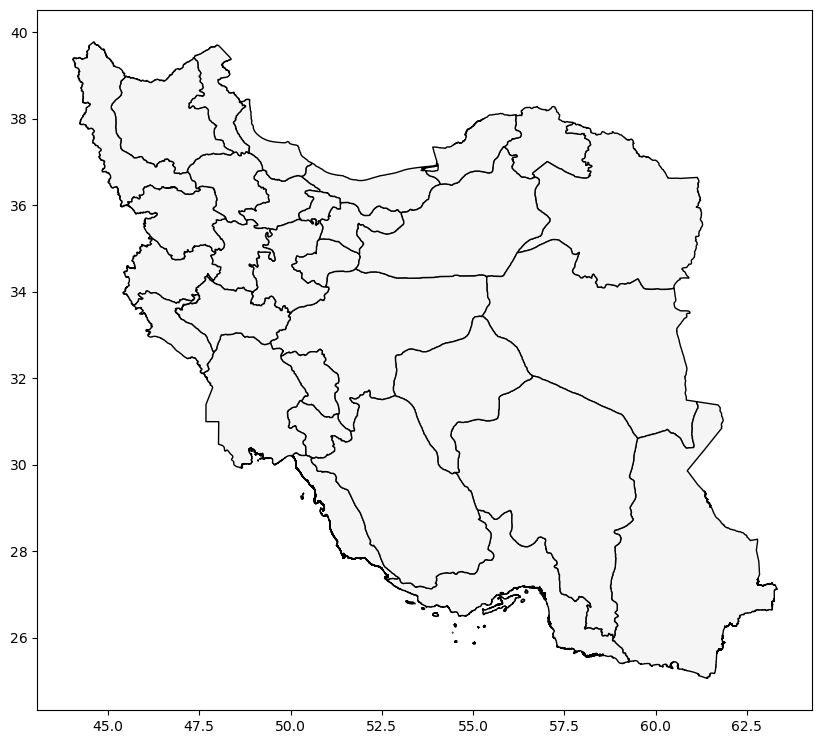

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

iran.plot(ax=ax, color="whitesmoke", edgecolor="black")

plt.show()

✅ Figure saved to: D:\Quera\Exercises\project01\divar-real-estate-ml\reports\figures\iran_ad_points.png


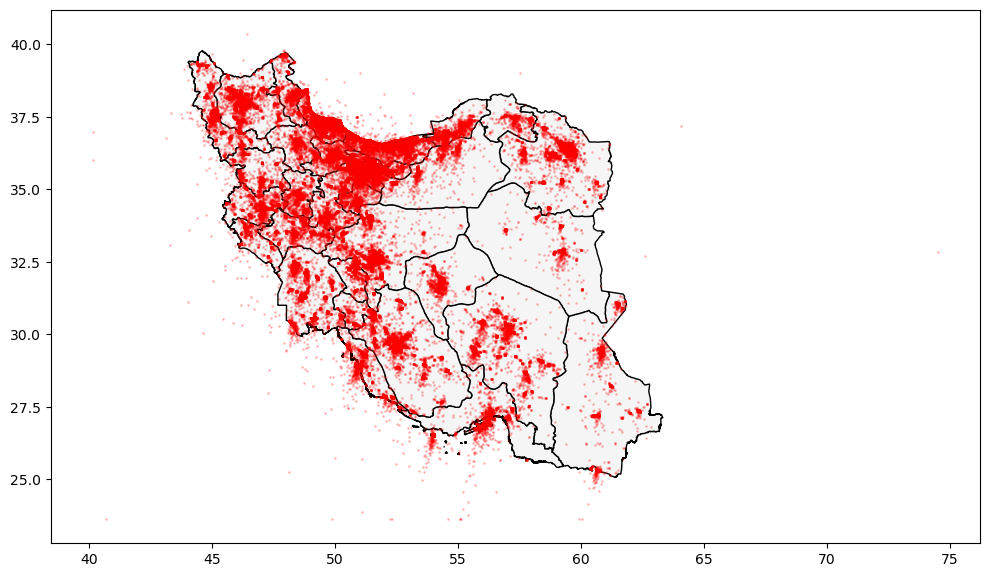

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))

iran.plot(ax=ax, color="whitesmoke", edgecolor="black")

geo_ads.plot(ax=ax, markersize=1, color="red", alpha=0.2)

plt.tight_layout()

save_figure("iran_ad_points")

plt.show()

In [21]:
import folium
from folium.plugins import HeatMap

In [22]:
iran_map = folium.Map(location=[32.5, 53.5], zoom_start=5, tiles="CartoDB positron")

In [23]:
heat_data = geo_df[["location_latitude", "location_longitude"]].values.tolist()

In [24]:
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.4).add_to(iran_map)

In [25]:
iran_map.save("../reports/figures/iran_heatmap.html")

In [26]:
city_density = geo_df["city_slug"].value_counts()

city_density.head(10)

city_slug
tehran               143082
mashhad               37358
karaj                 36037
isfahan               24772
shiraz                19947
tabriz                16877
andisheh-new-town     15405
rasht                 12352
kermanshah            10849
qom                    9403
Name: count, dtype: int64

✅ Figure saved to: D:\Quera\Exercises\project01\divar-real-estate-ml\reports\figures\top10_city_density.png


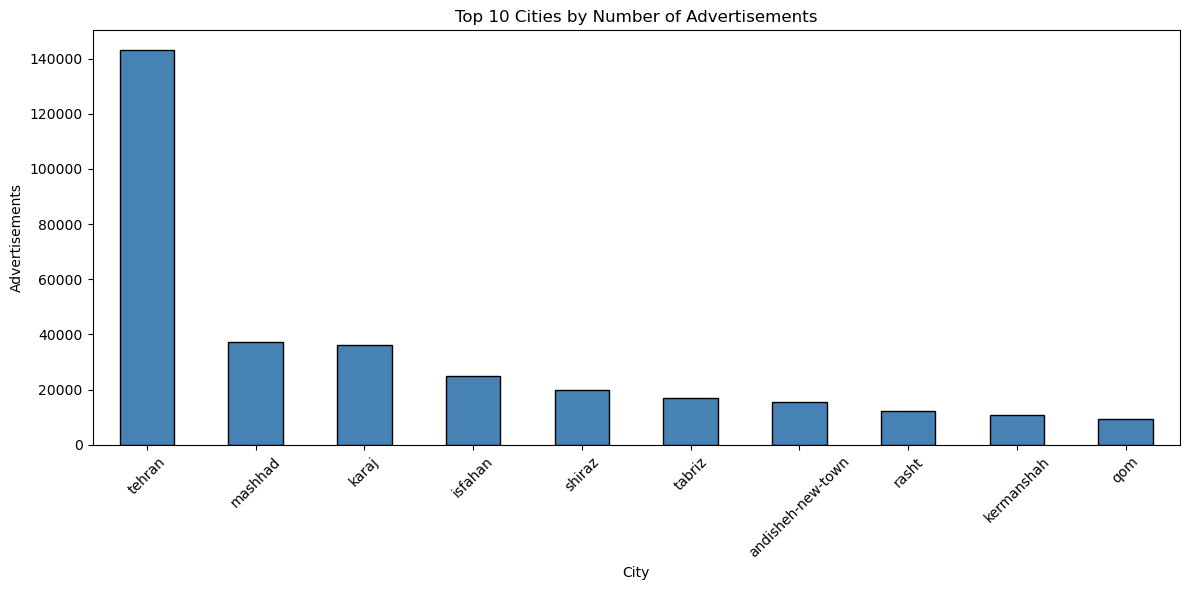

In [27]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import save_figure

city_density = geo_df["city_slug"].value_counts().head(10)

plt.figure(figsize=(12, 6))

city_density.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Top 10 Cities by Number of Advertisements")
plt.xlabel("City")
plt.ylabel("Advertisements")
plt.xticks(rotation=45)

plt.tight_layout()

save_figure("top10_city_density")

plt.show()

آگهی‌های املاک به‌صورت یکنواخت در کشور توزیع نشده‌اند. بیشترین تراکم در شهر تهران مشاهده می‌شود که احتمالاً به دلیل جمعیت بالا، حجم زیاد معاملات مسکن و تعداد بیشتر کاربران پلتفرم دیوار است. پس از تهران، شهرهای بزرگی مانند مشهد، اصفهان، شیراز و کرج نیز تراکم قابل توجهی دارند. همچنین در بسیاری از مناطق کم‌جمعیت یا روستایی تراکم آگهی‌ها بسیار کمتر است که می‌تواند ناشی از فعالیت کمتر بازار مسکن یا استفاده کمتر از این پلتفرم باشد.